In [276]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [277]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import sys
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option('display.max_columns', None)

# **Chạy model Time series**

In [278]:
Tserie_data = pd.read_csv("/content/drive/MyDrive/home-credit-default-risk/POS_CASH_balance.csv")
Tserie_data.tail(10)

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
10001348,2234984,191559,-22,6.0,0.0,Active,797,0
10001349,2340692,104125,-24,6.0,0.0,Active,944,0
10001350,2593362,198894,-20,12.0,0.0,Completed,0,0
10001351,2639809,288279,-25,6.0,0.0,Active,925,0
10001352,2700641,448867,-19,6.0,0.0,Active,843,0
10001353,2448283,226558,-20,6.0,0.0,Active,843,0
10001354,1717234,141565,-19,12.0,0.0,Active,602,0
10001355,1283126,315695,-21,10.0,0.0,Active,609,0
10001356,1082516,450255,-22,12.0,0.0,Active,614,0
10001357,1259607,174278,-52,16.0,0.0,Completed,0,0


In [279]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")


        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [219]:
missing_values_table(Tserie_data)

Your selected dataframe has 8 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values
CNT_INSTALMENT_FUTURE,26087,0.3
CNT_INSTALMENT,26071,0.3


In [280]:
app = pd.read_csv("/content/drive/MyDrive/home-credit-default-risk/application_train.csv", usecols=['SK_ID_CURR', 'TARGET'])

In [281]:
assert "SK_ID_CURR" in app.columns
assert "SK_ID_CURR" in Tserie_data.columns
assert "TARGET" in app.columns

In [282]:
valid_ids = set(app["SK_ID_CURR"])
Tserie_data = Tserie_data[Tserie_data["SK_ID_CURR"].isin(valid_ids)]


In [283]:
assert Tserie_data["SK_ID_CURR"].isin(valid_ids).all()


In [284]:
pos_features = [
    "MONTHS_BALANCE",
    "CNT_INSTALMENT",
    "CNT_INSTALMENT_FUTURE",
    "SK_DPD",
    "SK_DPD_DEF"
]
Tserie_data = Tserie_data[pos_features + ["SK_ID_CURR"]]


In [285]:
Tserie_data = Tserie_data.sort_values(
    ["SK_ID_CURR", "MONTHS_BALANCE"],
    ascending=[True, True]
)


In [286]:
SEQ_LEN = 12
F = len(pos_features)
Tserie_data[pos_features] = Tserie_data[pos_features].fillna(0)
PAD_VALUE = 0

In [287]:
def build_pos_sequence(df, seq_len, features):
    seqs = {}

    for sk_id, g in df.groupby("SK_ID_CURR"):
        data = g[features].values

        if len(data) >= seq_len:
            seq = data[-seq_len:]
        else:
            pad = np.zeros((seq_len - len(data), data.shape[1]))
            seq = np.vstack([pad, data])

        seqs[sk_id] = seq

    return seqs

pos_seq_dict = build_pos_sequence(Tserie_data, SEQ_LEN, pos_features)


In [288]:
app_idx = app.set_index("SK_ID_CURR")

final_ids = [sk_id for sk_id in pos_seq_dict.keys()
             if sk_id in app_idx.index]


In [289]:
ids_lstm = []
X_lstm = []

for sk_id in final_ids:
    X_lstm.append(pos_seq_dict[sk_id])
    ids_lstm.append(sk_id)

X_lstm = np.array(X_lstm)
ids_lstm = np.array(ids_lstm)
y = app_idx.loc[ids_lstm, "TARGET"].values

In [290]:
print(X_lstm.shape)      # (N, SEQ_LEN, F)
print(y.shape)      # (N,)
print(len(ids_lstm))     # = N


(289444, 12, 5)
(289444,)
289444


In [233]:

# Bước 1: Tạo một bộ Index duy nhất
indices = np.arange(len(y))

# Bước 2: Chia Index này thành 2 phần Train và Val
from sklearn.model_selection import train_test_split
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Bước 3: Dùng chung bộ Index này để cắt dữ liệu cho cả 2 nhánh
# Nhánh Wide
#X_train_wide = X_lstm[train_idx]
#X_val_wide = X_lstm[val_idx]

# Nhánh Deep
X_train_deep = X_lstm[train_idx]
X_val_deep = X_lstm[val_idx]

# Nhãn mục tiêu
y_train = y[train_idx]
y_val = y[val_idx]

In [234]:
scalers = {}
X_lstm_train_scaled = X_train_deep.copy()
X_lstm_val_scaled   = X_val_deep.copy()

N, T, F = X_train_deep.shape

for f in range(F):
    scaler = StandardScaler()

    train_feat = X_train_deep[:, :, f].reshape(-1, 1)
    mask = train_feat != 0

    scaler.fit(train_feat[mask].reshape(-1, 1))

    X_lstm_train_scaled[:, :, f] = scaler.transform(
        X_train_deep[:, :, f].reshape(-1, 1)
    ).reshape(N, T)

    X_lstm_val_scaled[:, :, f] = scaler.transform(
        X_val_deep[:, :, f].reshape(-1, 1)
    ).reshape(X_val_deep.shape[0], T)

    scalers[f] = scaler


In [235]:
print(X_lstm_train_scaled.shape)
print(X_lstm_val_scaled.shape)
print(y_train.shape)
print(y_val.shape)

(231555, 12, 5)
(57889, 12, 5)
(231555,)
(57889,)


In [236]:
assert ((X_lstm_train_scaled.sum(axis=2) != 0).sum(axis=1) > 0).all()


In [237]:
mb_idx = pos_features.index("MONTHS_BALANCE")
print(X_train_deep[0][:, mb_idx])


[  0. -36. -35. -34. -33. -32. -31. -30. -29. -28. -27. -26.]


In [238]:
for f in range(F):
    vals = X_lstm_train_scaled[:, :, f]
    vals = vals[vals != 0]
    print(f, round(vals.mean(), 3), round(vals.std(), 3))


0 0.073 0.993
1 -0.111 1.029
2 -0.204 0.978
3 -0.424 0.143
4 -0.119 0.098


In [239]:
print("Train:", np.bincount(y_train))
print("Val  :", np.bincount(y_val))


Train: [212658  18897]
Val  : [53165  4724]


In [240]:
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Masking, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [241]:
T = X_lstm_train_scaled.shape[1]
F = X_lstm_train_scaled.shape[2]

inp = Input(shape=(T, F), name="pos_input")

x = Masking(mask_value=0.0)(inp)

x = LSTM(
    units=64,
    return_sequences=False,
    dropout=0.25,
    recurrent_dropout=0.15
)(x)

x = BatchNormalization()(x)

x = Dense(32, activation="relu")(x)
x = Dropout(0.3)(x)

out = Dense(1, activation="sigmoid")(x)

model = Model(inputs=inp, outputs=out)


In [242]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["AUC"]
)


In [243]:
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pos_input           │ (None, 12, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 12, 5)     │          0 │ pos_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_7 (Masking) │ (None, 12, 5)     │          0 │ pos_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_11 (Any)        │ (None, 12)        │          0 │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 64)        │     17,920 │ masking_7[0][0],  │
│                     │                   │            │ any_11[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ lstm_11[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,161 (78.75 KB)

 Non-trainable params: 128 (512.00 B)

In [244]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight = dict(zip(classes, weights))


In [245]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]


In [246]:
history = model.fit(
    X_lstm_train_scaled,
    y_train,
    validation_data=(X_lstm_val_scaled, y_val),
    epochs=30,
    batch_size=512,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 42s 82ms/step - AUC: 0.5101 - loss: 0.7056 - val_AUC: 0.5416 - val_loss: 0.6954 - learning_rate: 0.0010
Epoch 2/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - AUC: 0.5206 - loss: 0.6907 - val_AUC: 0.5413 - val_loss: 0.6871 - learning_rate: 0.0010
Epoch 3/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - AUC: 0.5304 - loss: 0.6890 - val_AUC: 0.5480 - val_loss: 0.6897 - learning_rate: 0.0010
Epoch 4/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - AUC: 0.5294 - loss: 0.6888 - val_AUC: 0.5495 - val_loss: 0.6962 - learning_rate: 0.0010
Epoch 5/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - AUC: 0.5363 - loss: 0.6881 - val_AUC: 0.5529 - val_loss: 0.6806 - learning_rate: 0.0010
Epoch 6/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - AUC: 0.5355 - loss: 0.6881 - val_AUC: 0.5565 - val_loss: 0.6849 - learning_rate: 0.0010
Epoch 7/30
453/453 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - AUC: 0.5347 - loss: 0.6879 - val_AUC: 0.5467 - val_loss: 0.6877 - learning_rate:

In [247]:
best_val_auc = max(history.history["val_AUC"])
print("Best val AUC:", round(best_val_auc, 5))


Best val AUC: 0.56066


In [248]:
print(len(X_lstm_train_scaled))
print(len(y_train))

231555
231555


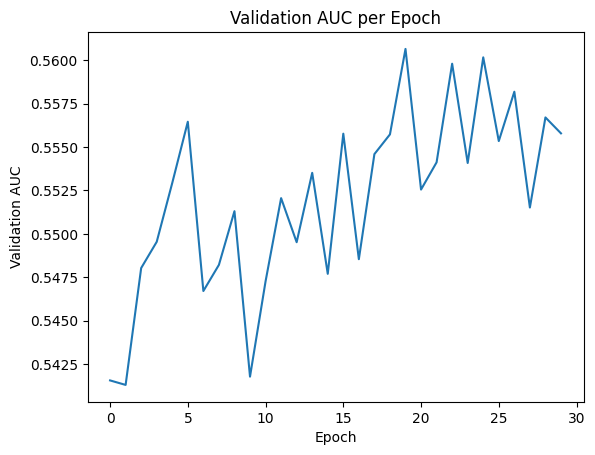

In [249]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["val_AUC"])
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC per Epoch")
plt.show()

In [250]:
len(ids_lstm), X_lstm.shape[0], len(y)



(289444, 289444, 289444)

# **Chạy model nhánh Wide branch**

In [251]:
static_data = pd.read_csv("/content/drive/MyDrive/static_data.csv")
static_data.head(20)

,NAME_INCOME_TYPE_index,NAME_EDUCATION_TYPE_index,OCCUPATION_TYPE_index,ORGANIZATION_TYPE_index,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_F,CODE_GENDER_M,CODE_GENDER_XNA,FLAG_OWN_CAR_N,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,SK_ID_PREV,AMT_APPLICATION,DAYS_DECISION,CNT_PAYMENT,NAME_CONTRACT_TYPE_index,NAME_CASH_LOAN_PURPOSE_index,NAME_CONTRACT_TYPE_ohe_0,NAME_CONTRACT_TYPE_ohe_1,NAME_CONTRACT_TYPE_ohe_2,NAME_CONTRACT_TYPE_ohe_3,NAME_CASH_LOAN_PURPOSE_ohe_0,NAME_CASH_LOAN_PURPOSE_ohe_1,NAME_CASH_LOAN_PURPOSE_ohe_2,NAME_CASH_LOAN_PURPOSE_ohe_3,NAME_CASH_LOAN_PURPOSE_ohe_4,NAME_CASH_LOAN_PURPOSE_ohe_5,NAME_CASH_LOAN_PURPOSE_ohe_6,NAME_CASH_LOAN_PURPOSE_ohe_7,NAME_CASH_LOAN_PURPOSE_ohe_8,NAME_CASH_LOAN_PURPOSE_ohe_9,NAME_CASH_LOAN_PURPOSE_ohe_10,NAME_CASH_LOAN_PURPOSE_ohe_11,NAME_CASH_LOAN_PURPOSE_ohe_12,NAME_CASH_LOAN_PURPOSE_ohe_13,NAME_CASH_LOAN_PURPOSE_ohe_14,NAME_CASH_LOAN_PURPOSE_ohe_15,NAME_CASH_LOAN_PURPOSE_ohe_16,NAME_CASH_LOAN_PURPOSE_ohe_17,NAME_CASH_LOAN_PURPOSE_ohe_18,NAME_CASH_LOAN_PURPOSE_ohe_19,NAME_CASH_LOAN_PURPOSE_ohe_20,NAME_CASH_LOAN_PURPOSE_ohe_21,NAME_CASH_LOAN_PURPOSE_ohe_22,NAME_CASH_LOAN_PURPOSE_ohe_23,NAME_CASH_LOAN_PURPOSE_ohe_24,NAME_CONTRACT_STATUS_label,CODE_REJECT_REASON_label,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MEDIAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CREDIT_ACTIVE_Active,BUREAU_CREDIT_ACTIVE_Bad debt,BUREAU_CREDIT_ACTIVE_Closed,BUREAU_CREDIT_ACTIVE_Sold,BUREAU_CREDIT_TYPE_Another type of loan,BUREAU_CREDIT_TYPE_Car loan,BUREAU_CREDIT_TYPE_Cash loan (non-earmarked),BUREAU_CREDIT_TYPE_Consumer credit,BUREAU_CREDIT_TYPE_Credit card,BUREAU_CREDIT_TYPE_Interbank credit,BUREAU_CREDIT_TYPE_Loan for business development,BUREAU_CREDIT_TYPE_Loan for purchase of shares (margin lending),BUREAU_CREDIT_TYPE_Loan for the purchase of equipment,BUREAU_CREDIT_TYPE_Loan for working capital replenishment,BUREAU_CREDIT_TYPE_Microloan,BUREAU_CREDIT_TYPE_Mobile operator loan,BUREAU_CREDIT_TYPE_Mortgage,BUREAU_CREDIT_TYPE_Real estate loan,BUREAU_CREDIT_TYPE_Unknown type of loan,BUREAU_COUNT,ACTIVE_AMT_CREDIT_SUM_MEAN,ACTIVE_AMT_CREDIT_SUM_MAX,ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,ACTIVE_AMT_CREDIT_SUM_DEBT_MAX,ACTIVE_DAYS_CREDIT_MEAN,ACTIVE_DAYS_CREDIT_MAX,HAS_BUREAU
0,7.0,4.0,8.0,5.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,100002,1,0,202500.000,406597.5,24700.5,351000.0,0.018801,-9461,-637,-3648.0,-2120,0.0,1,0,1,0,1.0,2,2,0.083037,0.262949,0.139376,-1134.0,1038818,179055.000000,-60

In [252]:
TARGET_COL = "TARGET"

X = static_data.drop(columns=[TARGET_COL])
y = static_data[TARGET_COL].values


In [253]:
pos_ids = set(Tserie_data["SK_ID_CURR"].unique())


In [174]:
n_pos_customers = Tserie_data["SK_ID_CURR"].nunique()
print(n_pos_customers)


289444


In [254]:
app_pos = static_data[static_data["SK_ID_CURR"].isin(pos_ids)].copy()
len(app_pos)


288277

In [258]:
y_pos = app_pos["TARGET"].values

X_wide = app_pos.drop(
    columns=["SK_ID_CURR", "TARGET"]
)


In [259]:
wide_features = X_wide.columns.tolist()

In [260]:
wide_fill_values = {
    col: X_wide[col].median()
    for col in X_wide.columns
}


In [261]:
for col, val in wide_fill_values.items():
    X_wide[col].fillna(val, inplace=True)


In [262]:
app_idx = app.set_index("SK_ID_CURR")


In [263]:
ids_lstm_safe = [i for i in ids_lstm if i in app_idx.index]


In [264]:
if "SK_ID_CURR" in X.columns:
    X = X.drop(columns=["SK_ID_CURR"])

In [299]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
wide_oof = np.zeros(len(y))

In [ ]:
# 1. Chuyển ids_lstm thành một DataFrame để dễ thực hiện join
df_ids_lstm = pd.DataFrame({'SK_ID_CURR': ids_lstm.astype(str), 'original_order': np.arange(len(ids_lstm))})

# 2. Đảm bảo SK_ID_CURR trong static_data cũng là kiểu chuỗi (string)
static_data['SK_ID_CURR'] = static_data['SK_ID_CURR'].astype(str)

# 3. Sử dụng merge để chỉ lấy những ID xuất hiện ở cả 2 tập (Giao thoa)
# Việc này giúp loại bỏ những ID bị thiếu trong static_data mà gây ra lỗi KeyError
matched_data = pd.merge(df_ids_lstm, static_data, on='SK_ID_CURR', how='inner')

# 4. Sắp xếp lại theo đúng thứ tự ban đầu của LSTM để khớp với mảng X_lstm
matched_data = matched_data.sort_values('original_order')

# 5. Cập nhật lại nhãn y và mảng X_lstm để khớp với những ID thực sự tồn tại ở cả 2 nhánh
# Lấy index của những dòng tìm thấy
keep_idx = matched_data['original_order'].values

y_final = y[keep_idx]
X_lstm_final = X_lstm[keep_idx] # X_lstm là mảng 3D của bạn

# 6. Chuẩn bị đầu vào Wide cuối cùng
X_wide_final = matched_data.drop(columns=['SK_ID_CURR', 'original_order', 'TARGET'], errors='ignore')

print(f"Số lượng mẫu sau khi đồng bộ: {len(y_final)}")

In [300]:
# 1. Chuyển ids_lstm thành một DataFrame để dễ thực hiện join
df_ids_lstm = pd.DataFrame({'SK_ID_CURR': ids_lstm.astype(str), 'original_order': np.arange(len(ids_lstm))})

# 2. Đảm bảo SK_ID_CURR trong static_data cũng là kiểu chuỗi (string)
static_data['SK_ID_CURR'] = static_data['SK_ID_CURR'].astype(str)

# 3. Sử dụng merge để chỉ lấy những ID xuất hiện ở cả 2 tập (Giao thoa)
# Việc này giúp loại bỏ những ID bị thiếu trong static_data mà gây ra lỗi KeyError
matched_data = pd.merge(df_ids_lstm, static_data, on='SK_ID_CURR', how='inner')

# 4. Sắp xếp lại theo đúng thứ tự ban đầu của LSTM để khớp với mảng X_lstm
matched_data = matched_data.sort_values('original_order')

# 5. Cập nhật lại nhãn y và mảng X_lstm để khớp với những ID thực sự tồn tại ở cả 2 nhánh
# Lấy index của những dòng tìm thấy
keep_idx = matched_data['original_order'].values

y_final = y[keep_idx]
X_lstm_final = X_lstm[keep_idx] # X_lstm là mảng 3D của bạn

# 6. Chuẩn bị đầu vào Wide cuối cùng
X_wide_final = matched_data.drop(columns=['SK_ID_CURR', 'original_order', 'TARGET'], errors='ignore')

print(f"Số lượng mẫu sau khi đồng bộ: {len(y_final)}")

Số lượng mẫu sau khi đồng bộ: 288277


In [265]:
# 1. Chuyển ids_lstm thành một DataFrame để dễ thực hiện join
df_ids_lstm = pd.DataFrame({'SK_ID_CURR': ids_lstm.astype(str), 'original_order': np.arange(len(ids_lstm))})

# 2. Đảm bảo SK_ID_CURR trong static_data cũng là kiểu chuỗi (string)
static_data['SK_ID_CURR'] = static_data['SK_ID_CURR'].astype(str)

# 3. Sử dụng merge để chỉ lấy những ID xuất hiện ở cả 2 tập (Giao thoa)
# Việc này giúp loại bỏ những ID bị thiếu trong static_data mà gây ra lỗi KeyError
matched_data = pd.merge(df_ids_lstm, static_data, on='SK_ID_CURR', how='inner')

# 4. Sắp xếp lại theo đúng thứ tự ban đầu của LSTM để khớp với mảng X_lstm
matched_data = matched_data.sort_values('original_order')

# 5. Cập nhật lại nhãn y và mảng X_lstm để khớp với những ID thực sự tồn tại ở cả 2 nhánh
# Lấy index của những dòng tìm thấy
keep_idx = matched_data['original_order'].values

y_final = y[keep_idx]
X_lstm_final = X_lstm[keep_idx] # X_lstm là mảng 3D của bạn

# 6. Chuẩn bị đầu vào Wide cuối cùng
X_wide_final = matched_data.drop(columns=['SK_ID_CURR', 'original_order', 'TARGET'], errors='ignore')

print(f"Số lượng mẫu sau khi đồng bộ: {len(y_final)}")

Số lượng mẫu sau khi đồng bộ: 288277


In [267]:
# 1. Cắt lại mảng LSTM (Deep) để chỉ còn 288.277 mẫu
X_lstm_final = X_lstm[keep_idx]

# 2. Cắt lại nhãn y chung để chỉ còn 288.277 mẫu
y_final = y[keep_idx]

# 3. Kiểm tra lại một lần cuối cho chắc chắn
print(f"Kích thước X_wide: {X_wide_final.shape[0]}")
print(f"Kích thước X_lstm: {X_lstm_final.shape[0]}")
print(f"Kích thước y:      {len(y_final)}")

# Nếu cả 3 đều là 288.277 -> Bạn đã thành công!

Kích thước X_wide: 288277
Kích thước X_lstm: 288277
Kích thước y:      288277


In [301]:
import pandas as pd
import numpy as np

# 1. Tạo một bảng "Mỏ neo" chứa ID và nhãn chuẩn từ file gốc
# Giả sử y là nhãn tương ứng với ids_lstm
df_anchor = pd.DataFrame({
    'SK_ID_CURR': ids_lstm.astype(str),
    'y_label': y
})

# 2. Thực hiện merge để lấy những ID giao thoa
# static_data nên chứa SK_ID_CURR làm cột hoặc index
matched_data = pd.merge(df_anchor, static_data, on='SK_ID_CURR', how='inner')

# 3. Lấy nhãn y_final TRỰC TIẾP từ bảng đã merge (Đảm bảo ID nào nhãn đó)
y_final = matched_data['y_label'].values

# 4. Lấy X_wide_final từ bảng đã merge
# Loại bỏ các cột phụ để chỉ còn đặc trưng huấn luyện
cols_to_drop = ['SK_ID_CURR', 'y_label', 'TARGET']
X_wide_final = matched_data.drop(columns=[c for c in cols_to_drop if c in matched_data.columns])

# 5. Cập nhật X_lstm_final dựa trên những ID còn sót lại
# Ta cần tìm vị trí của các ID trong matched_data so với mảng ids_lstm ban đầu
id_map = {id_val: i for i, id_val in enumerate(ids_lstm.astype(str))}
keep_idx = [id_map[str(id_val)] for id_val in matched_data['SK_ID_CURR']]
X_lstm_final = X_lstm[keep_idx]

print(f"Đồng bộ hoàn tất!")
print(f"Kích thước X_wide: {X_wide_final.shape}")
print(f"Kích thước X_lstm: {X_lstm_final.shape}")
print(f"Kích thước y_final: {y_final.shape}")

# KIỂM TRA TÍN HIỆU NGAY (Nếu > 0.5 là thành công)
from sklearn.metrics import roc_auc_score
# Chạy một model Logistic nhanh để test nhãn
from sklearn.linear_model import LogisticRegression
test_lr = LogisticRegression(max_iter=100).fit(X_wide_final[:10000], y_final[:10000])
test_auc = roc_auc_score(y_final[10000:20000], test_lr.predict_proba(X_wide_final[10000:20000])[:, 1])
print(f"AUC Test nhanh: {test_auc:.4f}")

✅ Đồng bộ hoàn tất!
Kích thước X_wide: (288277, 138)
Kích thước X_lstm: (288277, 12, 5)
Kích thước y_final: (288277,)
🚀 AUC Test nhanh: 0.5622


In [302]:
import pickle
import numpy as np
import os
import joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1. CẤU HÌNH ĐƯỜNG DẪN
SAVE_DIR = "/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train"
os.makedirs(SAVE_DIR, exist_ok=True)

# 2. CHUẨN BỊ DỮ LIỆU (Đã đồng bộ 288.277 mẫu)
# Đảm bảo bạn đã chạy cell đồng bộ ID trước đó
X_input = X_wide_final
y_input = y_final

wide_oof_logit = np.zeros(len(y_input))
logistic_artifacts = []

# 3. CHẠY K-FOLD VÀ THU THẬP ARTIFACTS
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Bắt đầu huấn luyện Stacking (Wide Branch) tại: {SAVE_DIR}")
print("-" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_input, y_input), 1):
    # Tách dữ liệu theo Index của Fold
    X_train_wide, X_val_wide = X_input.iloc[train_idx], X_input.iloc[val_idx]
    y_train, y_val = y_input[train_idx], y_input[val_idx]

    # Xử lý Outliers (Giới hạn giá trị cực đoan để Logistic ổn định hơn)
    X_train_wide = np.clip(X_train_wide, -1e6, 1e6)
    X_val_wide   = np.clip(X_val_wide, -1e6, 1e6)

    # Scaling: Quan trọng nhất với Logistic Regression
    scaler = MaxAbsScaler()
    X_train_wide_scaled = scaler.fit_transform(X_train_wide)
    X_val_wide_scaled   = scaler.transform(X_val_wide)

    # Huấn luyện mô hình Logistic Regression
    # C=0.5 giúp kiểm soát Overfitting, class_weight="balanced" giải quyết mất cân bằng dữ liệu
    lr_model = LogisticRegression(
        C=0.5, solver="liblinear", penalty="l2",
        class_weight="balanced", max_iter=200, random_state=42
    )
    lr_model.fit(X_train_wide_scaled, y_train)

    # Dự báo Logit (Raw score) thay vì xác suất 0-1 để giữ độ biến thiên tín hiệu
    wide_oof_logit[val_idx] = lr_model.decision_function(X_val_wide_scaled)

    # Đóng gói Model và Scaler của Fold này
    logistic_artifacts.append({
        'fold': fold,
        'model': lr_model,
        'scaler': scaler
    })

    # Tính AUC nhanh cho Fold hiện tại để theo dõi
    fold_auc = roc_auc_score(y_val, wide_oof_logit[val_idx])
    print(f"Fold {fold} Hoàn tất - AUC: {fold_auc:.4f}")

# 4. KIỂM TRA TỔNG THỂ (NẾU > 0.7 LÀ CỰC TỐT)
total_auc = roc_auc_score(y_input, wide_oof_logit)
print("-" * 50)
print(f"TỔNG KẾT AUC NHÁNH WIDE: {total_auc:.4f}")
print("-" * 50)

# ==========================================
# 5. LƯU ARTIFACTS RA GOOGLE DRIVE
# ==========================================

# A. Lưu danh sách Model & Scaler (Inference sau này)
with open(f"{SAVE_DIR}/logistic_stacking_artifacts.pkl", "wb") as f:
    pickle.dump(logistic_artifacts, f)

# B. Lưu danh sách tên cột (Đảm bảo thứ tự đặc trưng khi nạp dữ liệu Test)
with open(f"{SAVE_DIR}/wide_features.pkl", "wb") as f:
    pickle.dump(X_input.columns.tolist(), f)

# C. Lưu mảng OOF Logit (Đầu vào cho mô hình Wide & Deep tiếp theo)
np.save(f"{SAVE_DIR}/wide_oof_logit.npy", wide_oof_logit)

print(f"THÀNH CÔNG: Đã lưu 3 file quan trọng vào Drive!")

Bắt đầu huấn luyện Stacking (Wide Branch) tại: /content/drive/MyDrive/Home_credit_risk_ARTIFACT/train
--------------------------------------------------
Fold 1 Hoàn tất - AUC: 0.7557
Fold 2 Hoàn tất - AUC: 0.7479
Fold 3 Hoàn tất - AUC: 0.7463
Fold 4 Hoàn tất - AUC: 0.7487
Fold 5 Hoàn tất - AUC: 0.7527
--------------------------------------------------
TỔNG KẾT AUC NHÁNH WIDE: 0.7502
--------------------------------------------------
THÀNH CÔNG: Đã lưu 3 file quan trọng vào Drive!


# **Combie mô hình 2 nhanh wide và deep**

In [305]:
import tensorflow as tf
import numpy as np
import random
from sklearn.utils import shuffle

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [306]:
# 1. TRỘN DỮ LIỆU ĐỂ ĐẢM BẢO TÍNH KHÁCH QUAN
X_w_final, X_l_final, y_final_shuff = shuffle(
    wide_oof_logit.reshape(-1, 1),
    X_lstm_final,
    y_final,
    random_state=42
)

In [307]:
# 2. XÂY DỰNG CẤU TRÚC MÔ HÌNH
# --- Nhánh Wide (Dùng kết quả Logistic) ---
wide_in = tf.keras.Input(shape=(1,), name="wide_input")
# BatchNormalization cực kỳ quan trọng để ổn định tín hiệu Logit
w = tf.keras.layers.BatchNormalization()(wide_in)
w = tf.keras.layers.Dense(16, activation="relu")(w)

In [308]:
# --- Nhánh Deep (Dùng chuỗi LSTM) ---
deep_in = tf.keras.Input(shape=(X_l_final.shape[1], X_l_final.shape[2]), name="deep_input")
d = tf.keras.layers.Masking(mask_value=0.0)(deep_in)
d = tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.2)(d)
d = tf.keras.layers.LSTM(32, dropout=0.2)(d)
d = tf.keras.layers.Dense(32, activation="relu")(d)
d = tf.keras.layers.BatchNormalization()(d)

In [309]:
# --- Kết hợp ---
merged = tf.keras.layers.Concatenate()([w, d])
merged = tf.keras.layers.Dense(16, activation="relu")(merged)
output = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(merged)

model = tf.keras.Model(inputs=[wide_in, deep_in], outputs=output)


In [310]:
# --- COMPILE ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

In [311]:
# --- HUẤN LUYỆN (SỬ DỤNG BIẾN ĐÃ ĐỒNG BỘ) ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)
]

# 4. CHẠY HUẤN LUYỆN
history = model.fit(
    x={"wide_input": X_w_final, "deep_input": X_l_final},
    y=y_final_shuff,
    validation_split=0.2,
    epochs=30,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 55s 106ms/step - auc: 0.5942 - loss: 0.3379 - val_auc: 0.7538 - val_loss: 0.2495
Epoch 2/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 45s 100ms/step - auc: 0.7479 - loss: 0.2499 - val_auc: 0.7569 - val_loss: 0.2483
Epoch 3/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 46s 101ms/step - auc: 0.7500 - loss: 0.2493 - val_auc: 0.7592 - val_loss: 0.2471
Epoch 4/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 47s 104ms/step - auc: 0.7505 - loss: 0.2491 - val_auc: 0.7593 - val_loss: 0.2471
Epoch 5/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 46s 102ms/step - auc: 0.7520 - loss: 0.2487 - val_auc: 0.7573 - val_loss: 0.2477
Epoch 6/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 46s 101ms/step - auc: 0.7522 - loss: 0.2486 - val_auc: 0.7603 - val_loss: 0.2468
Epoch 7/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 46s 101ms/step - auc: 0.7521 - loss: 0.2486 - val_auc: 0.7607 - val_loss: 0.2467
Epoch 8/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 53s 117ms/step - auc: 0.7528 - loss: 0.2485 - val_auc: 0.7605 - val_loss: 0.2468
Epoch 9/30
451/451 ━━━━━━━━━━━━━

In [312]:
best_val_auc = max(history.history["val_auc"])
print("Best val AUC:", round(best_val_auc, 5))

Best val AUC: 0.76223


In [313]:
import os

SAVE_DIR = "/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train"
os.makedirs(SAVE_DIR, exist_ok=True)


In [314]:
model.save(f"{SAVE_DIR}/model.keras")

In [315]:
import pickle

with open(f"{SAVE_DIR}/scalers_deep.pkl", "wb") as f:
    pickle.dump(scalers, f)

In [316]:
with open(f"{SAVE_DIR}/wide_scaler.pkl", "wb") as f:
    pickle.dump(wide_scaler, f)


In [317]:
with open(f"{SAVE_DIR}/wide_fill_values.pkl", "wb") as f:
    pickle.dump(wide_fill_values, f)


In [318]:
import pickle

# 1. Lưu danh sách features cho nhánh Wide (33 cột đã chọn lọc)
with open(f"{SAVE_DIR}/wide_features.pkl", "wb") as f:
    pickle.dump(wide_features, f)

# 2. Lưu danh sách features cho nhánh Deep (5 cột)
with open(f"{SAVE_DIR}/pos_features.pkl", "wb") as f:
    pickle.dump(pos_features, f)

# 3. Lưu SEQ_LEN (có thể lưu vào file txt nhỏ hoặc pkl)
with open(f"{SAVE_DIR}/seq_len.pkl", "wb") as f:
    pickle.dump(SEQ_LEN, f)

print("Đã lưu features và cấu hình vào các file .pkl riêng biệt!")


Đã lưu features và cấu hình vào các file .pkl riêng biệt!


# Chạy kết quả trên tập test với các trọng số đã lưu

In [1]:
import pandas as pd
application_test_processed = pd.read_csv("/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/static_data_test.csv")
pos_test = pd.read_csv("/content/drive/MyDrive/home-credit-default-risk/POS_CASH_balance.csv")


In [2]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tqdm import tqdm


# 1. CẤU HÌNH ĐƯỜNG DẪN
SAVE_DIR = "/content/drive/MyDrive/Home_credit_risk_ARTIFACT/train"
DATA_DIR = "/content/drive/MyDrive/home-credit-default-risk"


# 2. LOAD CÁC FILE ĐÃ LƯU (ARTIFACTS)

print("--- Đang nạp Model và các tham số ---")
# Load model Wide & Deep chính
model_final = tf.keras.models.load_model(f"{SAVE_DIR}/model.keras", compile=False)

# Load danh sách các model Logistic (Artifacts)
with open(f"{SAVE_DIR}/logistic_stacking_artifacts.pkl", "rb") as f:
    logistic_artifacts = pickle.load(f)

# Load danh sách tên cột để reindex tập test cho đúng thứ tự
with open(f"{SAVE_DIR}/wide_features.pkl", "rb") as f:
    wide_features_list = pickle.load(f)

# Load tham số nhánh Deep
with open(f"{SAVE_DIR}/pos_features.pkl", "rb") as f:
    pos_features = pickle.load(f)
with open(f"{SAVE_DIR}/seq_len.pkl", "rb") as f:
    SEQ_LEN = pickle.load(f)
with open(f"{SAVE_DIR}/scalers_deep.pkl", "rb") as f:
    scalers_deep = pickle.load(f)


# 3. XỬ LÝ NHÁNH WIDE (TẠO LOGIT TỪ LOGISTIC)
print("--- Đang xử lý nhánh Wide (Stacking) ---")
app_test = pd.read_csv(f"{SAVE_DIR}/static_data_test.csv")
target_ids = app_test["SK_ID_CURR"].values

# Đảm bảo tập test có đúng số lượng và thứ tự cột như lúc train logistic
X_test_wide_raw = app_test.reindex(columns=wide_features_list, fill_value=0)
X_test_wide_raw = np.clip(X_test_wide_raw, -1e6, 1e6)

# Lấy logit từ tất cả các fold và tính trung bình
all_fold_logits = []
for i, item in enumerate(logistic_artifacts):
    lr_model = item['model']
    lr_scaler = item['scaler']

    # Scale tập test theo scaler của fold i
    X_test_scaled = lr_scaler.transform(X_test_wide_raw)

    # Lấy logit score
    fold_logit = lr_model.decision_function(X_test_scaled)
    all_fold_logits.append(fold_logit)
    print(f"Đã lấy logit từ Fold {i+1}")

# Tính trung bình cộng các fold để ra 1 cột duy nhất
X_test_wide_final = np.mean(all_fold_logits, axis=0).reshape(-1, 1).astype('float32')
print(f"Shape đầu vào Wide final: {X_test_wide_final.shape}") # (47800, 1)

--- Đang nạp Model và các tham số ---
--- Đang xử lý nhánh Wide (Stacking) ---
Đã lấy logit từ Fold 1
Đã lấy logit từ Fold 2
Đã lấy logit từ Fold 3
Đã lấy logit từ Fold 4
Đã lấy logit từ Fold 5
Shape đầu vào Wide final: (47800, 1)


In [3]:
# 4. XỬ LÝ NHÁNH DEEP (SEQUENCE)
print("--- Đang xử lý nhánh Deep (LSTM) ---")
pos_test = pd.read_csv(f"{DATA_DIR}/POS_CASH_balance.csv")
pos_test = pos_test[pos_test["SK_ID_CURR"].isin(target_ids)]

def build_pos_sequence_test(target_ids, pos_df, seq_len, features, scalers_dict):
    pos_grouped = pos_df.groupby("SK_ID_CURR")
    seqs_list = []
    for sk_id in tqdm(target_ids, desc="Tạo sequence"):
        if sk_id in pos_grouped.groups:
            g = pos_grouped.get_group(sk_id).sort_values("MONTHS_BALANCE")
            data_list = []
            for i, f in enumerate(features):
                x = g[[f]].values
                # Lưu ý: scalers_deep của bạn thường là list scaler theo index
                x_scaled = scalers_dict[i].transform(x)
                data_list.append(x_scaled)
            data = np.hstack(data_list)
            if len(data) >= seq_len:
                seq = data[-seq_len:]
            else:
                seq = np.vstack([np.zeros((seq_len-len(data), data.shape[1])), data])
        else:
            seq = np.zeros((seq_len, len(features)))
        seqs_list.append(seq)
    return np.array(seqs_list).astype('float32')

X_test_deep_final = build_pos_sequence_test(target_ids, pos_test, SEQ_LEN, pos_features, scalers_deep)

--- Đang xử lý nhánh Deep (LSTM) ---


Tạo sequence: 100%|██████████| 47800/47800 [03:19<00:00, 239.11it/s]


In [4]:
# 5. DỰ BÁO VÀ LƯU KẾT QUẢ

print("--- Đang thực hiện dự báo cuối cùng ---")
y_pred = model_final.predict([X_test_wide_final, X_test_deep_final], batch_size=512)

submission = pd.DataFrame({
    "SK_ID_CURR": target_ids,
    "TARGET": y_pred.flatten()
})

submission.to_csv(f"{SAVE_DIR}/submission_stacking_final.csv", index=False)
print(f"THÀNH CÔNG! File đã được lưu tại: {SAVE_DIR}/submission_stacking_final.csv")

--- Đang thực hiện dự báo cuối cùng ---
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
THÀNH CÔNG! File đã được lưu tại: /content/drive/MyDrive/Home_credit_risk_ARTIFACT/train/submission_stacking_final.csv


Thống kê mô tả xác suất:
count    47800.000000
mean         0.071814
std          0.068958
min          0.001287
25%          0.026064
50%          0.050717
75%          0.088507
max          0.722087
Name: TARGET, dtype: float64


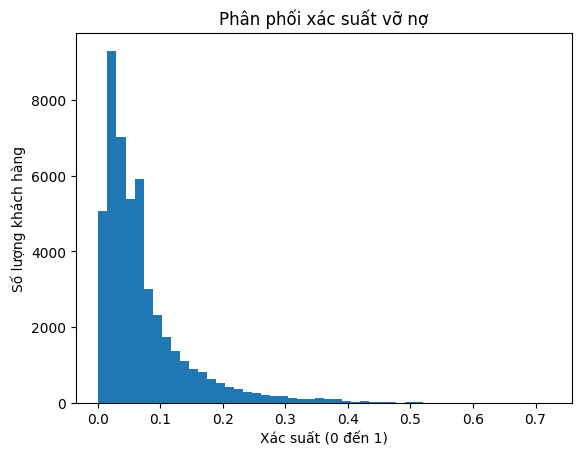

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

sub = pd.read_csv(f"{SAVE_DIR}/submission_final_fixed.csv")

print("Thống kê mô tả xác suất:")
print(sub['TARGET'].describe())

plt.hist(sub['TARGET'], bins=50)
plt.title("Phân phối xác suất vỡ nợ")
plt.xlabel("Xác suất (0 đến 1)")
plt.ylabel("Số lượng khách hàng")
plt.show()

In [6]:
import numpy as np
import pandas as pd

# Giả sử y_pred_prob là mảng xác suất bạn dự báo được từ tập test
probs_series = pd.Series(y_pred.flatten())

# 1. Tính các giá trị tứ phân vị
q1 = probs_series.quantile(0.25)
median = probs_series.quantile(0.50)
q3 = probs_series.quantile(0.75)
mean_val = probs_series.mean()

print(f"Q1 (25%): {q1:.4f}")
print(f"Median (50%): {median:.4f}")
print(f"Q3 (75%): {q3:.4f}")
print(f"Mean: {mean_val:.4f}")

# 2. Tìm vùng tập trung dữ liệu cao nhất (ví dụ giữa Median và Q3)
# Đây thường là vùng 'nhạy cảm' nhất của các mô hình tín dụng
suggested_threshold = (median + q3) / 2
print(f"--- Threshold đề xuất (Trung bình Median & Q3): {suggested_threshold:.4f} ---")

Q1 (25%): 0.0335
Median (50%): 0.0627
Q3 (75%): 0.1214
Mean: 0.0945
--- Threshold đề xuất (Trung bình Median & Q3): 0.0921 ---


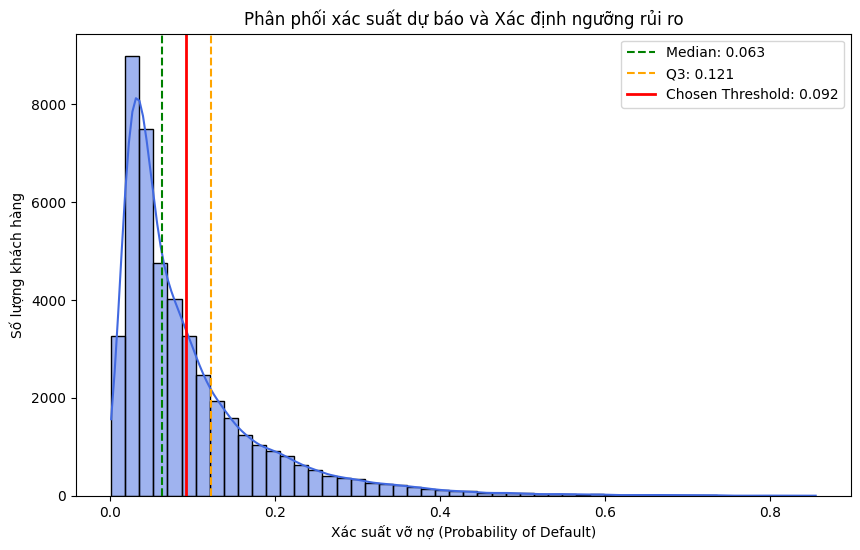

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(probs_series, bins=50, kde=True, color='royalblue')
plt.axvline(median, color='green', linestyle='--', label=f'Median: {median:.3f}')
plt.axvline(q3, color='orange', linestyle='--', label=f'Q3: {q3:.3f}')
plt.axvline(suggested_threshold, color='red', linewidth=2, label=f'Chosen Threshold: {suggested_threshold:.3f}')

plt.title("Phân phối xác suất dự báo và Xác định ngưỡng rủi ro")
plt.xlabel("Xác suất vỡ nợ (Probability of Default)")
plt.ylabel("Số lượng khách hàng")
plt.legend()
plt.show()

In [12]:
# 1. Dự báo xác suất nợ xấu cho toàn bộ tập dữ liệu đã đồng bộ
y_pred_all = model_final.predict({
    "wide_input": wide_oof_logit.reshape(-1, 1),
    "deep_input": X_lstm_final
})

# 2. Kiểm tra và loại bỏ NaN nếu có (Đề phòng dữ liệu đầu vào có NaN)
import numpy as np
nan_mask = np.isnan(y_pred_all).flatten()
if nan_mask.any():
    print(f"Phát hiện {nan_mask.sum()} giá trị NaN trong dự báo. Đang xử lý...")
    # Thay thế NaN bằng giá trị trung bình hoặc 0 để không cháy code
    y_pred_all = np.nan_to_num(y_pred_all, nan=0.0)

# 3. Tính toán các chỉ số trên nhãn y_final (nhãn chuẩn 288.277 mẫu)
from sklearn.metrics import roc_auc_score, roc_curve

auc_test = roc_auc_score(y_final, y_pred_all)
gini_test = 2 * auc_test - 1

print(f"AUC Score: {auc_test:.4f}")
print(f"Gini Coefficient: {gini_test:.4f}")

# 4. Vẽ biểu đồ ROC
fpr, tpr, thresholds = roc_curve(y_final, y_pred_all)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Wide & Deep Model (AUC = {auc_test:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Tỉ lệ báo động giả)')
plt.ylabel('True Positive Rate (Tỉ lệ bắt đúng nợ xấu)')
plt.title('Biểu đồ ROC Curve - Đánh giá mô hình Tín dụng')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

NameError: name 'wide_oof_logit' is not defined

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# --- BƯỚC 1: TÍNH TOÁN CÁC MỐC TỨ PHÂN VỊ ---
# y_pred_all là xác suất từ mô hình Wide & Deep vừa chạy
probs_series = pd.Series(y_pred_all.flatten())

q1 = probs_series.quantile(0.25)
median = probs_series.quantile(0.50)
q3 = probs_series.quantile(0.75)

print(f"Mốc Q1 (25% thấp nhất): {q1:.4f}")
print(f"Mốc Median (50%): {median:.4f}")
print(f"Mốc Q3 (75% thấp nhất): {q3:.4f}")

# --- BƯỚC 2: CHỌN NGƯỠNG TỐI ƯU DỰA TRÊN Q3 ---
# Trong tín dụng, ta thường quan tâm đến nhóm 25% rủi ro cao nhất (trên Q3)
# Bạn có thể dùng suggested_threshold = (median + q3) / 2 như ý tưởng của bạn
optimal_threshold = (median + q3) / 2
print(f"\n Ngưỡng đề xuất từ phân phối dữ liệu: {optimal_threshold:.4f}")

# --- BƯỚC 3: TẠO NHÃN DỰ BÁO VÀ VẼ CONFUSION MATRIX ---
y_pred_label = (y_pred_all > optimal_threshold).astype(int)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_final, y_pred_label)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Dự báo (0: Tốt, 1: Xấu)')
plt.ylabel('Thực tế (0: Tốt, 1: Xấu)')
plt.title(f'Confusion Matrix tại ngưỡng tối ưu {optimal_threshold:.4f}')
plt.show()

# --- BƯỚC 4: BÁO CÁO CHI TIẾT ---
print("\n--- Classification Report ---")
print(classification_report(y_final, y_pred_label))

NameError: name 'y_pred_all' is not defined

In [11]:
# Sắp xếp xác suất từ cao xuống thấp
results = pd.DataFrame({'y_true': y_final, 'y_prob': y_pred_all.flatten()})
results = results.sort_values(by='y_prob', ascending=False)

# Chia dữ liệu thành 10 phần (Deciles)
results['decile'] = pd.qcut(results['y_prob'], 10, labels=False, duplicates='drop')
results['decile'] = 9 - results['decile'] # Đảo ngược để decile 0 là rủi ro cao nhất

# Tính số nợ xấu trong từng phần
bad_dist = results.groupby('decile')['y_true'].sum() / results['y_true'].sum() * 100

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bad_dist.plot(kind='bar', color='salmon')
plt.title('Tỷ lệ nợ xấu mô hình "bắt" được theo từng phân đoạn 10% khách hàng')
plt.xlabel('Phân đoạn rủi ro (0: Cao nhất -> 9: Thấp nhất)')
plt.ylabel('% Tổng số nợ xấu bắt được')
plt.show()

NameError: name 'y_final' is not defined